In [1]:
print("'Aarif Rahmaan Jalaluddin Faqiih") # Tuliskan nama lengkap Anda
print("103112430182") # Tuliskan NIM Anda
print("IF-12-06") # Tuliskan kelas Anda
print("https://colab.research.google.com/drive/1kQNTnq3MiqccBoY4cS93ANUHwCoNuNXO?usp=sharing")
print("https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2010%20SOAL%20LATIHAN")

'Aarif Rahmaan Jalaluddin Faqiih
103112430182
IF-12-06
https://colab.research.google.com/drive/1kQNTnq3MiqccBoY4cS93ANUHwCoNuNXO?usp=sharing
https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2010%20SOAL%20LATIHAN


Tabel Heuristik (Euclidean Distance ke Bucharest):
----------------------------------------
  Oradea: 6.4
  Zerind: 6.41
  Arad: 6.22
  Timisoara: 6.18
  Lugoj: 5.54
  Mehadia: 5.0
  Drobeta: 5.22
  Craiova: 4.12
  Sibiu: 3.61
  Rimnicu Vilcea: 2.55
  Pitesti: 1.58
  Fagaras: 2.51
  Bucharest: 0.0
  Giurgiu: 1.12
  Urziceni: 1.04
  Vaslui: 2.5
  Iasi: 3.16
  Neamt: 3.5
  Hirsova: 2.06
  Eforie: 2.92
----------------------------------------

Hasil Penelusuran Greedy Best-First Search (Eropa):
  Arad -> Sibiu -> Fagaras -> Bucharest


/tmp/ipykernel_17843/1861487444.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


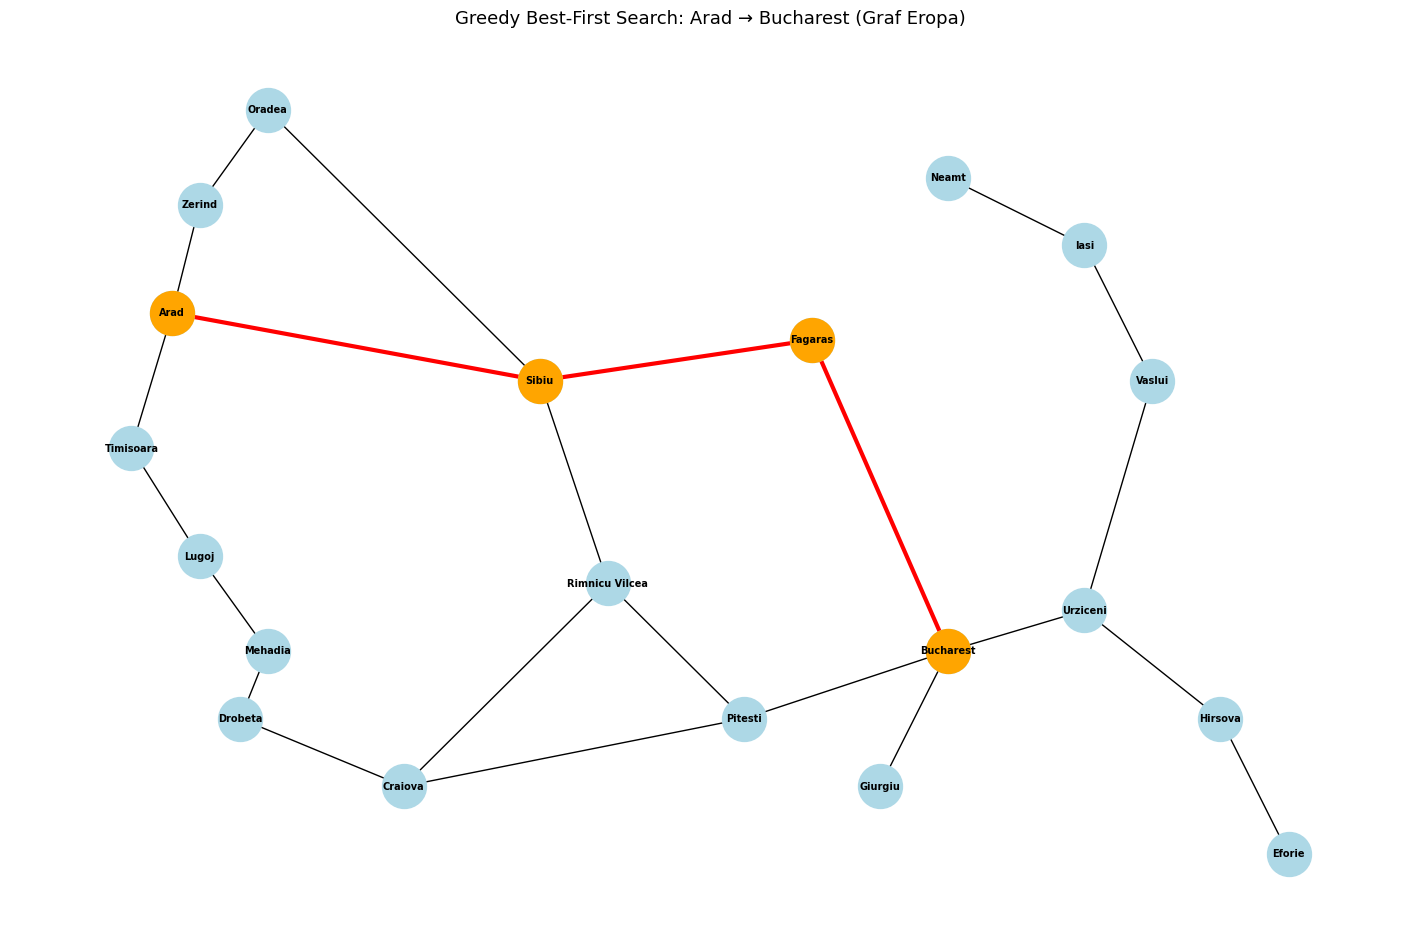

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# ============================================================
# 1. INISIALISASI GRAF BERBOBOT (WEIGHTED GRAPH)
# ============================================================
G_eropa = nx.Graph()

# ============================================================
# 2. KOORDINAT (X, Y) UNTUK EUCLIDEAN DISTANCE
# ============================================================
pos_eropa = {
    "Oradea": (1.5, 9.5),
    "Zerind": (1.0, 8.8),
    "Arad": (0.8, 8.0),
    "Timisoara": (0.5, 7.0),
    "Lugoj": (1.0, 6.2),
    "Mehadia": (1.5, 5.5),
    "Drobeta": (1.3, 5.0),
    "Craiova": (2.5, 4.5),
    "Sibiu": (3.5, 7.5),
    "Rimnicu Vilcea": (4.0, 6.0),
    "Pitesti": (5.0, 5.0),
    "Fagaras": (5.5, 7.8),
    "Bucharest": (6.5, 5.5),
    "Giurgiu": (6.0, 4.5),
    "Urziceni": (7.5, 5.8),
    "Vaslui": (8.0, 7.5),
    "Iasi": (7.5, 8.5),
    "Neamt": (6.5, 9.0),
    "Hirsova": (8.5, 5.0),
    "Eforie": (9.0, 4.0)
}

# ============================================================
# 3. TAMBAHKAN EDGE BERBOBOT (WEIGHTED EDGES)
# ============================================================
edges_eropa = [
    ("Oradea", "Zerind", 71),
    ("Zerind", "Arad", 75),
    ("Arad", "Timisoara", 118),
    ("Timisoara", "Lugoj", 111),
    ("Lugoj", "Mehadia", 70),
    ("Mehadia", "Drobeta", 75),
    ("Drobeta", "Craiova", 120),
    ("Craiova", "Pitesti", 138),
    ("Craiova", "Rimnicu Vilcea", 146),
    ("Pitesti", "Bucharest", 101),
    ("Bucharest", "Giurgiu", 90),
    ("Bucharest", "Urziceni", 85),
    ("Urziceni", "Hirsova", 98),
    ("Hirsova", "Eforie", 86),
    ("Urziceni", "Vaslui", 142),
    ("Vaslui", "Iasi", 92),
    ("Iasi", "Neamt", 87),
    ("Sibiu", "Oradea", 151),
    ("Sibiu", "Arad", 140),
    ("Sibiu", "Rimnicu Vilcea", 80),
    ("Sibiu", "Fagaras", 99),
    ("Fagaras", "Bucharest", 211),
    ("Rimnicu Vilcea", "Pitesti", 97)
]

G_eropa.add_weighted_edges_from(edges_eropa)

# ============================================================
# 4. HILANGKAN DATA WEIGHT (MEMBUAT SALINAN GRAF TANPA BOBOT)
# ============================================================
G_eropa_unweighted = nx.Graph()
G_eropa_unweighted.add_nodes_from(G_eropa.nodes())
G_eropa_unweighted.add_edges_from(G_eropa.edges())

# ============================================================
# 5. FUNGSI HEURISTIK EUCLIDEAN DISTANCE KE GOAL
# ============================================================
def get_heuristic_eropa(pos, goal_node):
    h = {}
    x2, y2 = pos[goal_node]
    for node in pos:
        x1, y1 = pos[node]
        dist = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        h[node] = round(dist, 2)
    return h

# ============================================================
# 6. IMPLEMENTASI GREEDY BFS
# ============================================================
def greedy_best_first_search_eropa(graph, start, goal, pos):
    h = get_heuristic_eropa(pos, goal)

    print(f"Tabel Heuristik (Euclidean Distance ke {goal}):")
    print("-" * 40)
    for node, value in h.items():
        print(f"  {node}: {value}")
    print("-" * 40)

    path = [start]
    visited = set([start])
    current = start

    while current != goal:
        neighbors = list(graph.neighbors(current))
        unvisited_neighbors = [n for n in neighbors if n not in visited]

        if not unvisited_neighbors:
            print("Pencarian gagal: tidak ada tetangga yang bisa dikunjungi.")
            break

        next_node = min(unvisited_neighbors, key=lambda n: h[n])

        path.append(next_node)
        visited.add(next_node)
        current = next_node

    return path

# ============================================================
# 7. JALANKAN PENCARIAN
# ============================================================
source_eropa = "Arad"
goal_eropa = "Bucharest"

path_eropa = greedy_best_first_search_eropa(
    G_eropa_unweighted, source_eropa, goal_eropa, pos_eropa
)

print(f"\nHasil Penelusuran Greedy Best-First Search (Eropa):")
print(f"  {' -> '.join(path_eropa)}")

# ============================================================
# 8. VISUALISASI
# ============================================================
plt.figure(figsize=(14, 9))

# Gambar semua node dan edge
nx.draw(G_eropa_unweighted, pos_eropa,
        with_labels=True,
        node_color='lightblue',
        node_size=1000,
        font_size=7,
        font_weight='bold')

# Tandai node pada jalur hasil pencarian
nx.draw_networkx_nodes(G_eropa_unweighted, pos_eropa,
                       nodelist=path_eropa,
                       node_color='orange',
                       node_size=1000)

# Tandai edge pada jalur hasil pencarian
path_edges_eropa = list(zip(path_eropa, path_eropa[1:]))
nx.draw_networkx_edges(G_eropa_unweighted, pos_eropa,
                       edgelist=path_edges_eropa,
                       edge_color='red',
                       width=3)

plt.title(f"Greedy Best-First Search: {source_eropa} → {goal_eropa} (Graf Eropa)", fontsize=13)
plt.tight_layout()
plt.show()

# **Penjelasan**

1. Membuat graf kosong

G_eropa = nx.Graph() perintah ini membuat sebuah graf kosong (belum ada node maupun edge). Graf ini nantinya akan diisi dengan node dan edge berbobot.

2. Koordinat tiap kota (Euclidean distance)

pos_eropa adalah dictionary yang menyimpan pasangan (x, y) untuk setiap nama kota. Contoh: "Arad": (0.8, 8.0). Koordinat ini digunakan untuk menghitung jarak lurus (Euclidean) antar kota.

3. Menambahkan edge berbobot

edges_eropa berisi daftar (kota_asal, kota_tujuan, bobot). Bobot di sini adalah jarak sebenarnya (dalam km). Perintah G_eropa.add_weighted_edges_from(edges_eropa) menambahkan semua edge tersebut ke graf. Jadi G_eropa sekarang adalah graf lengkap dengan bobot.

4. Membuat salinan graf tanpa bobot

G_eropa_unweighted = nx.Graph() adalah graf baru kosong. add_nodes_from dan add_edges_from menyalin semua node dan edge dari G_eropa, tetapi tanpa menyertakan bobot. Tujuannya agar algoritma Greedy Best-First Search (GBFS) pada kode ini hanya perlu mengetahui struktur koneksi (tetangga), tidak menggunakan bobot edge. Yang dipakai adalah nilai heuristik (jarak Euclidean ke goal).

5. Fungsi heuristik Euclidean

def get_heuristic_eropa(pos, goal_node):
- Fungsi ini menerima pos (koordinat semua node) dan goal_node (kota tujuan).
- Hitung jarak Euclidean dari setiap node ke goal_node : dist = sqrt((x2-x1)² + (y2-y1)²)
- Hasilnya dibulatkan 2 desimal lalu disimpan dalam dictionary h.
- Fungsi mengembalikan h yang berisi taksiran jarak tiap kota ke goal.

6. Implementasi Greedy Best-First Search (GBFS)

def greedy_best_first_search_eropa(graph, start, goal, pos):
- Langkah pertama: panggil get_heuristic_eropa(pos, goal) untuk mendapat tabel heuristik.
- Cetak tabel tersebut ke layar (menggunakan print).
- Inisialisasi path = [start], visited = {start}, current = start.
- Selama current belum sama dengan goal: Cari semua tetangga dari current. Filter hanya tetangga yang belum dikunjungi. Jika kosong, pencarian gagal (break). Pilih next_node dari unvisited_neighbors yang memiliki nilai heuristik paling kecil (paling dekat ke goal). Tambahkan next_node ke path dan visited, lalu set current = next_node.
- Ulangi sampai current == goal. Fungsi mengembalikan path (urutan kota dari start ke goal).

7. Menjalankan pencarian

source_eropa = "Arad" dan goal_eropa = "Bucharest". Panggil greedy_best_first_search_eropa(G_eropa_unweighted, source_eropa, goal_eropa, pos_eropa).

Tabel Heuristik (Euclidean Distance ke Malang):
----------------------------------------
  Jakarta: 8.06
  Bandung: 7.28
  Cirebon: 5.83
  Semarang: 4.24
  Yogyakarta: 3.16
  Surakarta: 2.24
  Surabaya: 2.0
  Malang: 0.0
----------------------------------------

Hasil Penelusuran Greedy Best-First Search (Pulau Jawa):
  Bandung -> Yogyakarta -> Surakarta -> Malang


/tmp/ipykernel_17843/1546728214.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


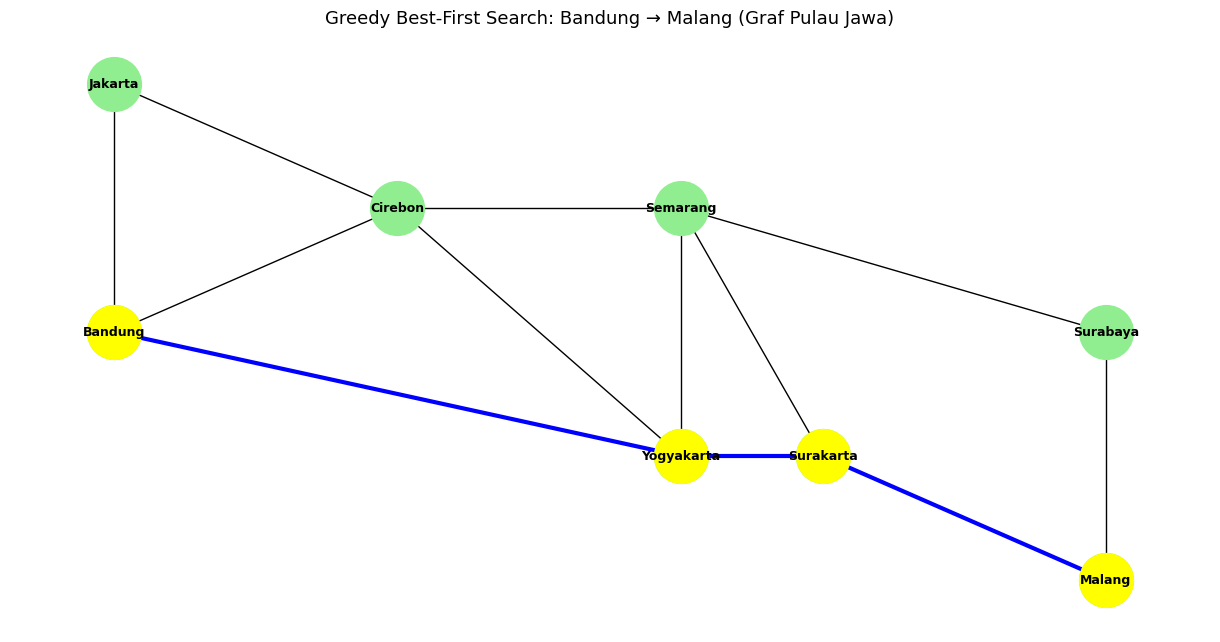

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# ============================================================
# 1. INISIALISASI GRAF BERBOBOT (WEIGHTED GRAPH)
# ============================================================
G_jawa = nx.Graph()

# ============================================================
# 2. KOORDINAT (X, Y) UNTUK EUCLIDEAN DISTANCE
# ============================================================
pos_jawa = {
    "Jakarta": (0, 5),
    "Bandung": (0, 3),
    "Cirebon": (2, 4),
    "Semarang": (4, 4),
    "Yogyakarta": (4, 2),
    "Surakarta": (5, 2),
    "Surabaya": (7, 3),
    "Malang": (7, 1)
}

# ============================================================
# 3. TAMBAHKAN EDGE BERBOBOT (WEIGHTED EDGES)
# ============================================================
edges_jawa = [
    ("Jakarta", "Cirebon", 327),
    ("Jakarta", "Bandung", 270),
    ("Bandung", "Cirebon", 120),
    ("Cirebon", "Semarang", 305),
    ("Semarang", "Yogyakarta", 109),
    ("Semarang", "Surakarta", 97),
    ("Surakarta", "Yogyakarta", 60),
    ("Surakarta", "Malang", 370),
    ("Surabaya", "Malang", 94),
    ("Surabaya", "Semarang", 369),
    ("Bandung", "Yogyakarta", 373),
    ("Yogyakarta", "Cirebon", 210)
]

G_jawa.add_weighted_edges_from(edges_jawa)

# ============================================================
# 4. HILANGKAN DATA WEIGHT (MEMBUAT SALINAN GRAF TANPA BOBOT)
# ============================================================
G_jawa_unweighted = nx.Graph()
G_jawa_unweighted.add_nodes_from(G_jawa.nodes())
G_jawa_unweighted.add_edges_from(G_jawa.edges())

# ============================================================
# 5. FUNGSI HEURISTIK EUCLIDEAN DISTANCE KE GOAL
# ============================================================
def get_heuristic_jawa(pos, goal_node):
    h = {}
    x2, y2 = pos[goal_node]
    for node in pos:
        x1, y1 = pos[node]
        dist = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        h[node] = round(dist, 2)
    return h

# ============================================================
# 6. IMPLEMENTASI GREEDY BFS
# ============================================================
def greedy_best_first_search_jawa(graph, start, goal, pos):
    h = get_heuristic_jawa(pos, goal)

    print(f"Tabel Heuristik (Euclidean Distance ke {goal}):")
    print("-" * 40)
    for node, value in h.items():
        print(f"  {node}: {value}")
    print("-" * 40)

    path = [start]
    visited = set([start])
    current = start

    while current != goal:
        neighbors = list(graph.neighbors(current))
        unvisited_neighbors = [n for n in neighbors if n not in visited]

        if not unvisited_neighbors:
            print("Pencarian gagal: tidak ada tetangga yang bisa dikunjungi.")
            break

        next_node = min(unvisited_neighbors, key=lambda n: h[n])

        path.append(next_node)
        visited.add(next_node)
        current = next_node

    return path

# ============================================================
# 7. JALANKAN PENCARIAN
# ============================================================
source_jawa = "Bandung"
goal_jawa = "Malang"

path_jawa = greedy_best_first_search_jawa(
    G_jawa_unweighted, source_jawa, goal_jawa, pos_jawa
)

print(f"\nHasil Penelusuran Greedy Best-First Search (Pulau Jawa):")
print(f"  {' -> '.join(path_jawa)}")

# ============================================================
# 8. VISUALISASI
# ============================================================
plt.figure(figsize=(12, 6))

# Gambar semua node dan edge
nx.draw(G_jawa_unweighted, pos_jawa,
        with_labels=True,
        node_color='lightgreen',
        node_size=1500,
        font_size=9,
        font_weight='bold')

# Tandai node pada jalur hasil pencarian
nx.draw_networkx_nodes(G_jawa_unweighted, pos_jawa,
                       nodelist=path_jawa,
                       node_color='yellow',
                       node_size=1500)

# Tandai edge pada jalur hasil pencarian
path_edges_jawa = list(zip(path_jawa, path_jawa[1:]))
nx.draw_networkx_edges(G_jawa_unweighted, pos_jawa,
                       edgelist=path_edges_jawa,
                       edge_color='blue',
                       width=3)

plt.title(f"Greedy Best-First Search: {source_jawa} → {goal_jawa} (Graf Pulau Jawa)", fontsize=13)
plt.tight_layout()
plt.show()

# **Penjelasan**

1. Inisialisasi graf berbobot

Di sini dibuat graf kosong dengan nx.Graph(). Nama variabelnya G_jawa. Graf ini nanti akan diisi node dan edge yang mewakili kota‑kota di Jawa.

2. Koordinat untuk Euclidean distance

Variabel pos_jawa berisi dictionary. Key-nya nama kota, value-nya pasangan koordinat (x, y). Koordinat ini hanya untuk menghitung jarak lurus (Euclidean) antar kota secara matematis, bukan jarak jalan sesungguhnya. Contoh: Jakarta di (0,5), Bandung di (0,3), Surabaya di (7,3), Malang di (7,1).

3. Tambahkan edge berbobot (weighted edges)

edges_jawa berisi daftar tuple (kota_asal, kota_tujuan, bobot). Bobot di sini adalah jarak tempuh antar kota dalam kilometer (nilai real dari peta). Lalu G_jawa.add_weighted_edges_from(edges_jawa) memasukkan semua edge itu ke graf. Jadi graf G_jawa sekarang punya node dan edge dengan bobot jarak sesungguhnya.

4. Hilangkan data bobot

Tujuannya: algoritma Greedy Best-First Search (GBFS) hanya perlu tahu struktur edge (siapa terhubung ke siapa), tidak pakai bobot asli. Bobot asli hanya buat referensi, tapi heuristiknya tetap pakai Euclidean. Maka dibuat graf baru G_jawa_unweighted dengan node dan edge yang sama persis, cuma tanpa atribut bobot.

5. Fungsi heuristik Euclidean distance ke goal

get_heuristic_jawa(pos, goal_node) menghitung jarak Euclidean dari setiap node ke node tujuan (goal_node). Rumus Euclidean: sqrt((x2-x1)^2 + (y2-y1)^2). Hasil perhitungan disimpan dalam dictionary h yang key-nya nama kota, value-nya jarak (dibulatkan 2 desimal). Fungsi ini dipanggil untuk menghasilkan tabel heuristik yang nanti dipakai GBFS dalam memilih langkah.

6. Implementasi Greedy Best-First Search

Fungsi greedy_best_first_search_jawa(graph, start, goal, pos) bekerja seperti ini:
- Pertama, panggil get_heuristic_jawa untuk mendapatkan h (jarak Euclidean tiap node ke goal).
- Inisialisasi path = [start], visited = {start}, current = start.
- Selama current != goal: Cari tetangga dari current dengan graph.neighbors(current). Ambil yang belum dikunjungi (if n not in visited). Jika tidak ada tetangga yang bisa dikunjungi, pencarian gagal. Pilih next_node sebagai tetangga yang punya nilai heuristik terkecil (paling dekat ke goal secara Euclidean). Caranya min(..., key=lambda n: h[n]). next_node ditambahkan ke path, ditandai visited, lalu current digeser ke next_node.
- Ulangi sampai current == goal atau gagal.
- Fungsi mengembalikan urutan node dari start ke goal (jalur hasil).
- Pada kode ini, GBFS menggunakan graf tanpa bobot, tapi pemilihan langkah sepenuhnya berdasarkan heuristik Euclidean, bukan jarak tempuh asli.

7. Jalankan pencarian

source_jawa = "Bandung", goal_jawa = "Malang". Lalu panggil fungsi GBFS dengan parameter G_jawa_unweighted, source, goal, dan pos_jawa. Hasil jalur dicetak, misalnya: Bandung -> Cirebon -> ... -> Malang. Dari sini, kita bisa lihat urutan kota yang dilewati. Karena heuristiknya cuma perkiraan jarak garis lurus, jalur yang dihasilkan mungkin bukan jalur terpendek secara real (belum tentu optimal), tapi GBFS cenderung cepat karena langsung mengarah ke goal.